In [1]:
import numpy as np
from torchvision.models import vgg11_bn,VGG11_BN_Weights 
import torch.nn as nn
from torch.utils.data import DataLoader
from scipy.special import lambertw
from sklearn.cluster import KMeans
import torch
import torch.nn as nn
import torch.optim as optim
import copy
import torch
import numpy as np
import random
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import CIFAR10
from torchvision import transforms
from sklearn.metrics import confusion_matrix
import torch.nn.functional as F
import os
import pandas as pd
from sklearn.model_selection import KFold
from torch.optim.lr_scheduler import ReduceLROnPlateau


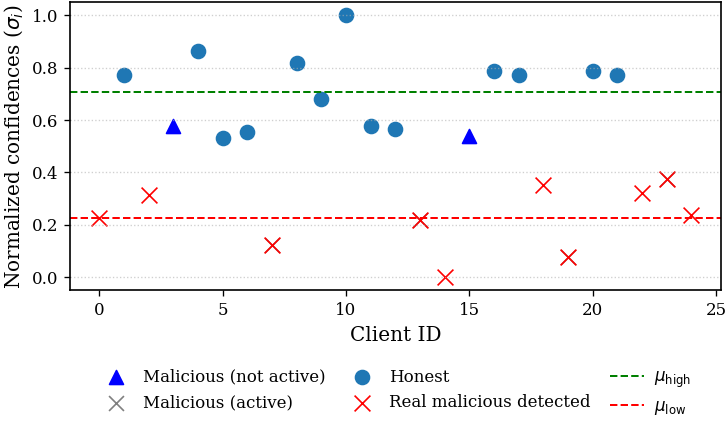

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def classify_clients_by_confidence(normalized_confidences):
    client_ids = list(normalized_confidences.keys())
    confidences = np.array(list(normalized_confidences.values())).reshape(-1, 1)

    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    kmeans.fit(confidences)
    centroids = kmeans.cluster_centers_.flatten()

    mu_lower, mu_upper = np.min(centroids), np.max(centroids)

    honest_clients = set()
    malicious_clients = set()

    for client_id, sigma_i in normalized_confidences.items():
        if abs(sigma_i - mu_upper) < abs(sigma_i - mu_lower):
            honest_clients.add(client_id)
        else:
            malicious_clients.add(client_id)

    return honest_clients, malicious_clients, mu_lower, mu_upper

def plot_confidence_clustering_paper(
    normalized_confidences,
    honest_clients,
    malicious_clients,
    mu_lower,
    mu_upper,
    figsize=(7.5, 4.5),
    outfile=None
):
    import matplotlib.pyplot as plt
    import numpy as np

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.linewidth": 1.0,
        "figure.dpi": 120,
        "savefig.dpi": 600,
    })

    ids = sorted(normalized_confidences.keys())
    sigmas = np.array([float(normalized_confidences[i]) for i in ids])

    # Ground truth
    client_cattivi_veri = [3, 7, 13, 15, 19, 23]
    client_cattivi_attivi = [7, 13, 19, 23]
    client_cattivi_non_attivi = set(client_cattivi_veri) - set(client_cattivi_attivi)

    # Categorie (coerenti col tuo codice originale)
    x_1 = [i for i in ids if i in client_cattivi_non_attivi and i not in malicious_clients]
    y_1 = [normalized_confidences[i] for i in x_1]

    x_2 = [i for i in ids if i in client_cattivi_attivi]
    y_2 = [normalized_confidences[i] for i in x_2]

    x_h = [
        i for i in ids
        if i in honest_clients
        and i not in client_cattivi_non_attivi
        and i not in client_cattivi_attivi
    ]
    y_h = [normalized_confidences[i] for i in x_h]

    x_m = [i for i in ids if i in malicious_clients]
    y_m = [normalized_confidences[i] for i in x_m]

    fig, ax = plt.subplots(figsize=figsize)

    # --- scatter (STESSI COLORI) ---
    ax.scatter(x_1, y_1, marker="^", color="blue",  s=70, label="Malicious (not active)")
    ax.scatter(x_2, y_2, marker="x", color="grey", s=80, label="Malicious (active)")
    ax.scatter(x_h, y_h, marker="o",               s=70, label="Honest")
    ax.scatter(x_m, y_m, marker="x", color="red",  s=90, label="Real malicious detected")

    # Centroidi
    ax.axhline(mu_upper, linestyle="--", color="green", linewidth=1.2, label=r"$\mu_{\mathrm{high}}$")
    ax.axhline(mu_lower, linestyle="--", color="red",   linewidth=1.2, label=r"$\mu_{\mathrm{low}}$")

    # Assi
    ax.set_xlabel("Client ID")
    ax.set_ylabel("Normalized confidences ($\sigma_i$)")
    ax.set_ylim(min(sigmas.min(), mu_lower) - 0.05,
                max(sigmas.max(), mu_upper) + 0.05)

    # Grid minimal (y only)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.8, alpha=0.6)

    # 🔹 LEGENDA SOTTO, FUORI
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.22),
        ncol=3,
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,
    )

    # spazio extra per la legenda
    fig.subplots_adjust(bottom=0.28)

    if outfile:
        fig.savefig(outfile)

    plt.show()



# ---------------- ESEMPIO USO ----------------
if __name__ == "__main__":
    normalized_confidences = {0: np.float64(0.22510801094604455), 1: np.float64(0.7728171143732068), 2: np.float64(0.3148860781474113), 3: np.float64(0.5787784906642358), 4: np.float64(0.8647189032756983), 5: np.float64(0.5310430995665564), 6: np.float64(0.5550099157565709), 7: np.float64(0.12159591970428779), 8: np.float64(0.8174628597049158), 9: np.float64(0.6804080080285925), 10: np.float64(1.0), 11: np.float64(0.5782689479709558), 12: np.float64(0.5649178483522771), 13: np.float64(0.22002555979714256), 14: np.float64(0.0), 15: np.float64(0.540085745689639), 16: np.float64(0.7891309447485795), 17: np.float64(0.7728918678883845), 18: np.float64(0.3506764764161738), 19: np.float64(0.07835643983413886), 20: np.float64(0.7889119145168195), 21: np.float64(0.7732412918778874), 22: np.float64(0.3227862086750318), 23: np.float64(0.3745797133583118), 24: np.float64(0.23736797678424845)}
    honest, malicious, mu_lower, mu_upper = classify_clients_by_confidence(normalized_confidences)

    plot_confidence_clustering_paper(
        normalized_confidences, honest, malicious, mu_lower, mu_upper,
        figsize=(7.0, 4.0),              # <-- “normale”
        outfile="confidence_round150.pdf" # oppure .png
    )
